In [1]:
import matplotlib.pyplot as plt
from astroplan import FixedTarget
from astropy import units as u
from astropy.coordinates import SkyCoord
from src.finder_charts import FinderChart, InstrumentFOV, Slit, savefig

# Simple finder chart

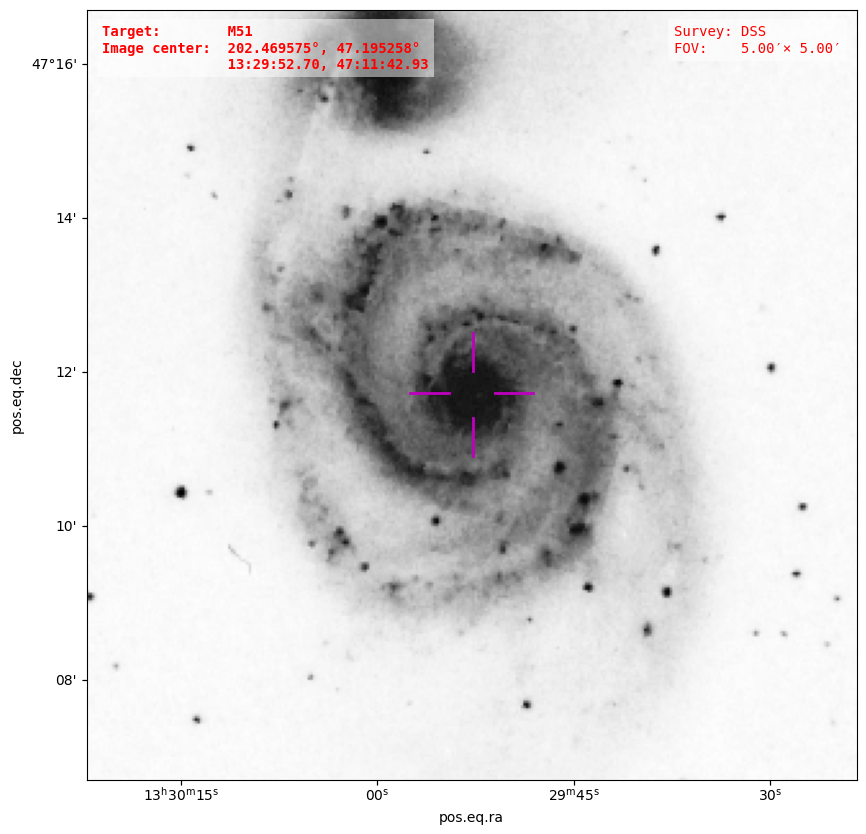

In [2]:
target = FixedTarget.from_name("M51")
chart = FinderChart(target)
chart.get_image(fov_radius=5 * u.arcmin)
ax = chart.plot_image()
chart.plot_reticle(ax)
savefig("plots/example_chart_1.png")

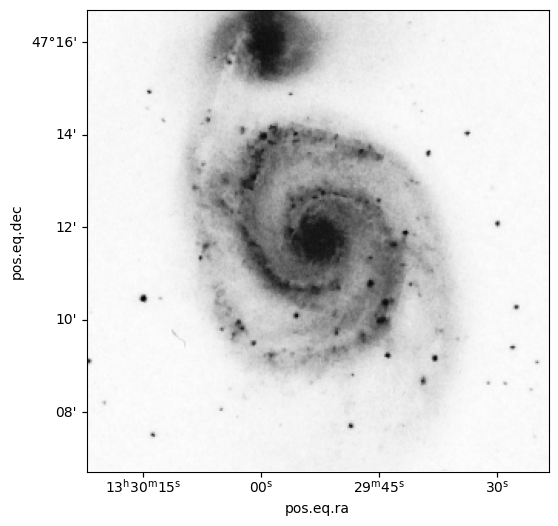

In [3]:
# Clean version without text and markers

target = FixedTarget.from_name("M51")
chart = FinderChart(target)
chart.get_image(fov_radius=5 * u.arcmin)

fig,ax = plt.subplots(figsize=(6,6))
ax = chart.plot_image(ax=ax, show_details=False)
savefig("plots/example_chart_1b.png")

# Finder chart with instrument FOV

- The example shows the FOV of the ALFOSC instrument on the Nordic Optical telescope.
- The user can create their own rectangular/circular FOV using similar function. 
- Create your own InstrumentFOV class if your FOV is something different

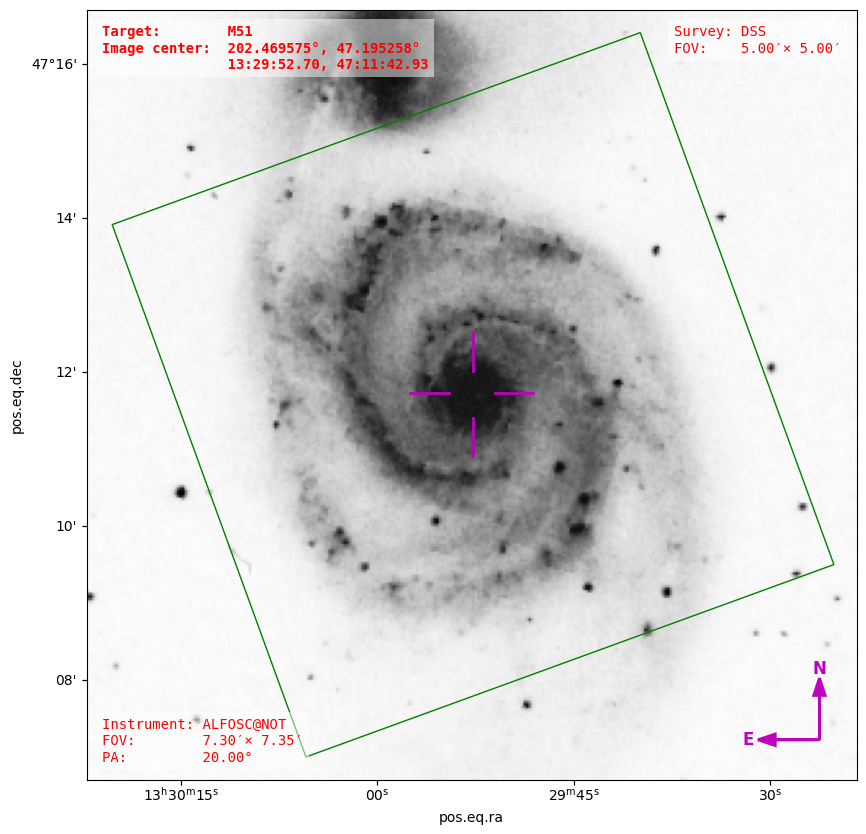

In [4]:
target = FixedTarget.from_name("M51")

instrument_fov = InstrumentFOV(
    name="ALFOSC@NOT",
    shape="rectangle",
    width=2048 * 0.2138 * u.arcsec,
    height=2064 * 0.2138 * u.arcsec,
    position_angle=20 * u.deg,
)

chart = FinderChart(target)
chart.get_image(fov_radius=5 * u.arcmin)
ax = chart.plot_image()
chart.plot_reticle(ax)
chart.plot_instrument_fov(instrument_fov, ax)
chart.plot_compass(
    ax,
    frac_length = 0.08,
    x_frac = 0.95,
    y_frac = 0.05,
    color = "m",
    linewidth = 2.0,
    fontsize = 12,
)
savefig("plots/example_chart_2.pdf")

# Finder chart with a slit

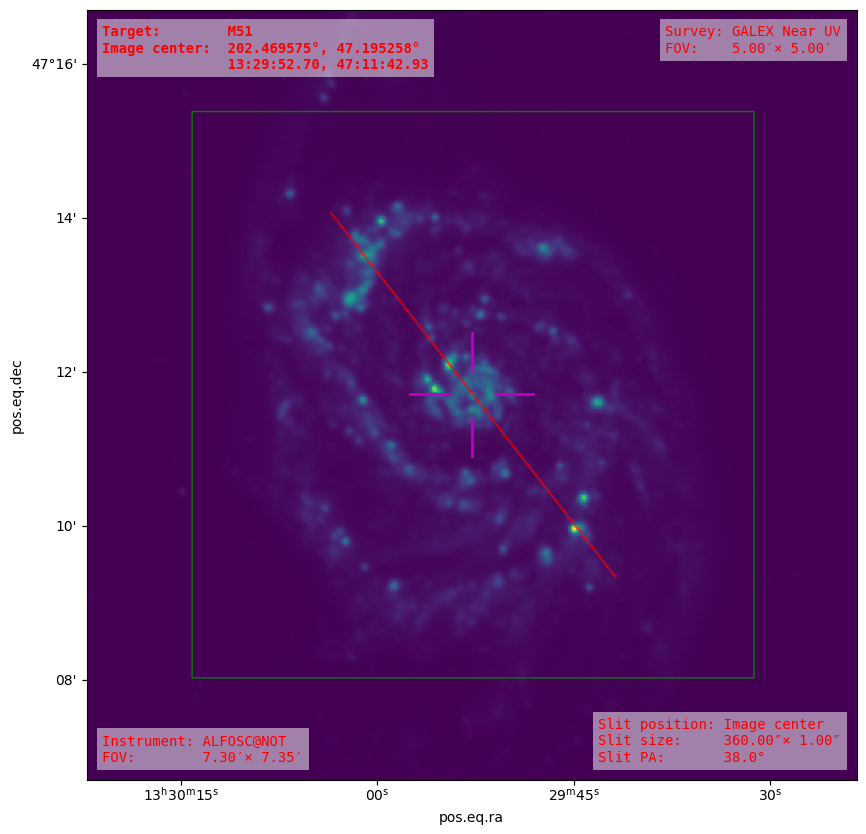

In [5]:
target = FixedTarget.from_name("M51")

instrument_fov = InstrumentFOV(
    name="ALFOSC@NOT",
    shape="rectangle",
    width=2048 * 0.2138 * u.arcsec,
    height=2064 * 0.2138 * u.arcsec,
)

slit = Slit(
    target.ra,
    target.dec,
    6 * u.arcmin,
    1 * u.arcsec,
    position_angle=38 * u.deg,
)

chart = FinderChart(target)
chart.get_image(fov_radius=5 * u.arcmin, survey='GALEX Near UV', pixels=1000)
ax = chart.plot_image(cmap='viridis')
chart.plot_reticle(ax)
chart.plot_instrument_fov(instrument_fov, ax)
chart.plot_slit(slit, ax)
savefig("plots/example_chart_3.png")

# Finder chart with multiple slits

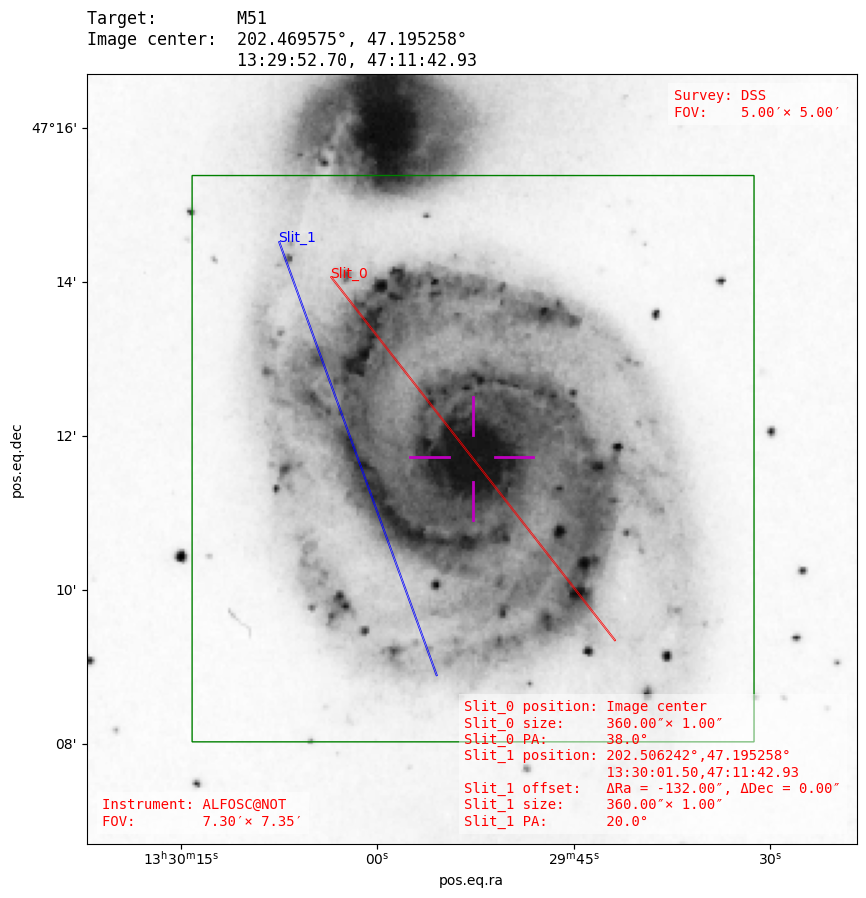

In [6]:
target = FixedTarget.from_name("M51")

instrument_fov = InstrumentFOV(
    name="ALFOSC@NOT",
    shape="rectangle",
    width=2048 * 0.2138 * u.arcsec,
    height=2064 * 0.2138 * u.arcsec,
)

slit_0 = Slit(
    target.ra,
    target.dec,
    6 * u.arcmin,
    1 * u.arcsec,
    position_angle=38 * u.deg,
)

slit_1 = Slit(
    target.ra + 2.2 * u.arcmin,
    target.dec,
    6 * u.arcmin,
    1 * u.arcsec,
    position_angle=20 * u.deg,
    color="b",
)

chart = FinderChart(target)
chart.get_image(fov_radius=5 * u.arcmin)
# Stop showing the object name in the default top left corner.
ax = chart.plot_image(show_details=False)
# Manually adding a title using the chart.target_label
ax.set_title(chart.target_label, ha='left', x=0, family="monospace")
# Manually adding a servey details using the chart.image_label
ax.text(
    0.98,
    0.98,
    chart.image_label,
    va="top",
    ha="right",
    ma="left",
    transform=ax.transAxes,
    color="r",
    family="monospace",
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.5),
)

chart.plot_reticle(ax)
chart.plot_instrument_fov(instrument_fov, ax)
chart.plot_slits([slit_0, slit_1], ax)
savefig("plots/example_chart_4.png")

# Finder chart with zoomin to particular targets

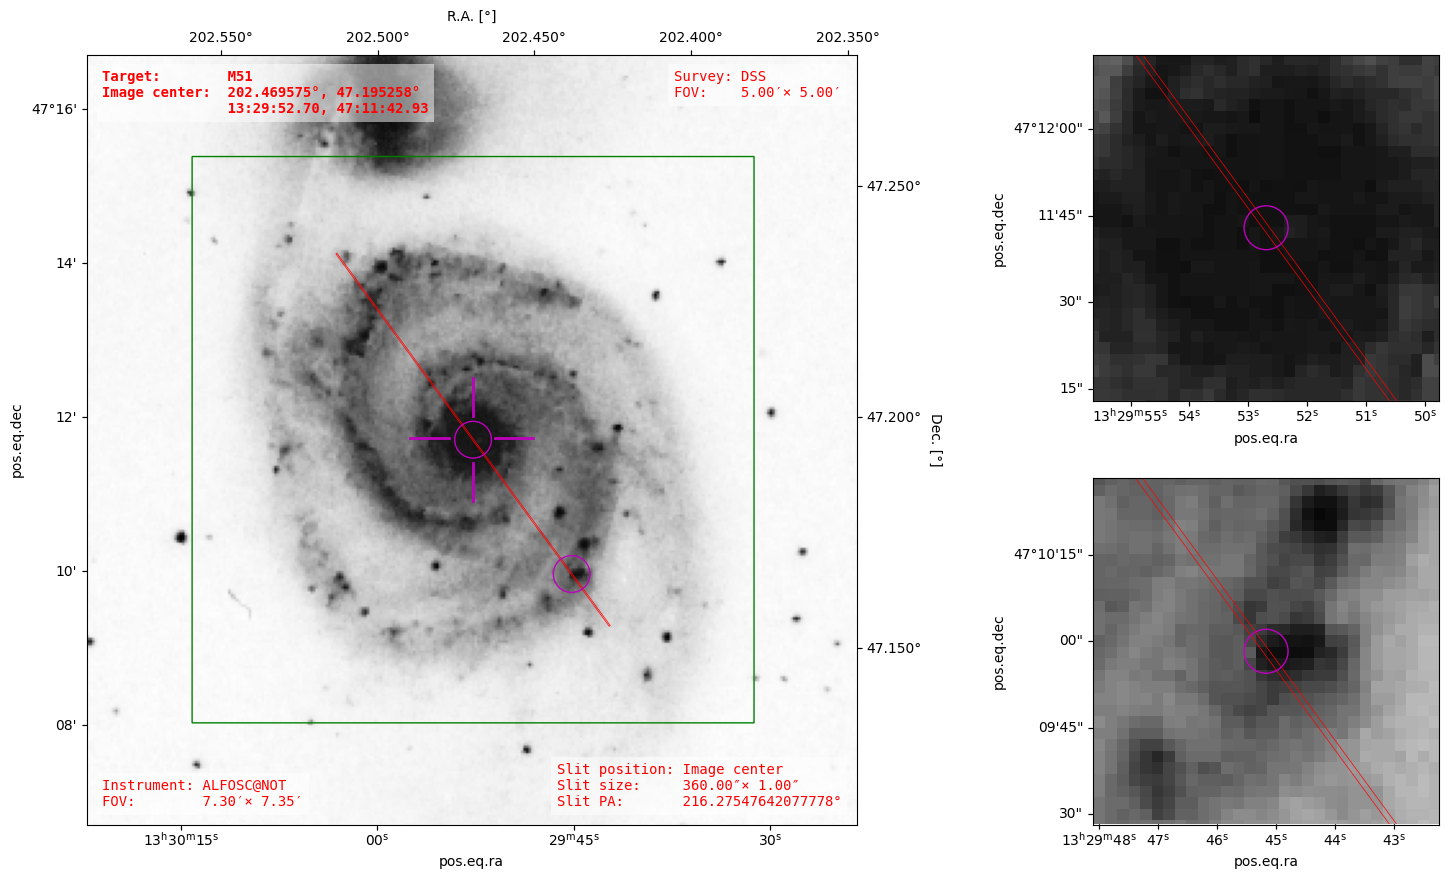

In [7]:
def create_slit_for_two_targets(target_0, target_1):
    """
    Helper function to align the slit to fall on two targets.
    The first target is kept at the center of the slit.
    """
    c_0 = target_0.coord
    c_1 = target_1.coord
    pa = c_0.position_angle(c_1)
    slit = Slit(
        c_0.ra,
        c_0.dec,
        6 * u.arcmin,
        1 * u.arcsec,
        position_angle=pa,
    )
    return slit


# Define targets
target = FixedTarget.from_name("M51")
target_secondary = FixedTarget(SkyCoord(ra=202.43819 * u.deg, dec=47.16618 * u.deg))

instrument_fov = InstrumentFOV(
    name="ALFOSC@NOT",
    shape="rectangle",
    width=2048 * 0.2138 * u.arcsec,
    height=2064 * 0.2138 * u.arcsec,
)

# Create a slit crossing the two targets
slit = create_slit_for_two_targets(target, target_secondary)

# Make the basic finder chart
chart = FinderChart(target)
chart.get_image(fov_radius=5 * u.arcmin)
ax = chart.plot_image(show_degrees=True)
chart.plot_reticle(ax)
chart.plot_instrument_fov(instrument_fov, ax)
chart.plot_slit(slit, ax)


# Add zoom-ins for the two targets
ax0 = ax.inset_axes((1.3, 0.55, 0.45, 0.45))
ax1 = ax.inset_axes((1.3, 0.0, 0.45, 0.45))
# Target 0
ax0 = chart.plot_image(ax=ax0, cmap="grey_r", show_degrees=False, show_details=False)
chart.plot_slit(slit, ax=ax0, show_details=False)
chart.plot_instrument_fov(instrument_fov, ax=ax0, show_details=False)
chart.rescale_image(ax0, chart.coord.ra, chart.coord.dec, fov_radius=30 * u.arcsec)
# Target secondary
ax1 = chart.plot_image(ax=ax1, cmap="grey_r", show_degrees=False, show_details=False)
chart.plot_slit(slit, ax=ax1, show_details=False)
chart.plot_instrument_fov(instrument_fov, ax=ax1, show_details=False)
chart.rescale_image(ax1, ra=target_secondary.ra, dec=target_secondary.dec, fov_radius=30 * u.arcsec)

# Highlighting the two targets in the main finder chart
center_pix = chart.wcs.world_to_pixel(target.coord)
ax.scatter(*center_pix, marker="o", fc="none", ec="m", s=700)
center_pix = chart.wcs.world_to_pixel(target_secondary.coord)
ax.scatter(*center_pix, marker="o", fc="none", ec="m", s=700)

savefig("plots/example_chart_5.png")

# Finder chart for a Multi-Object Spectra observations

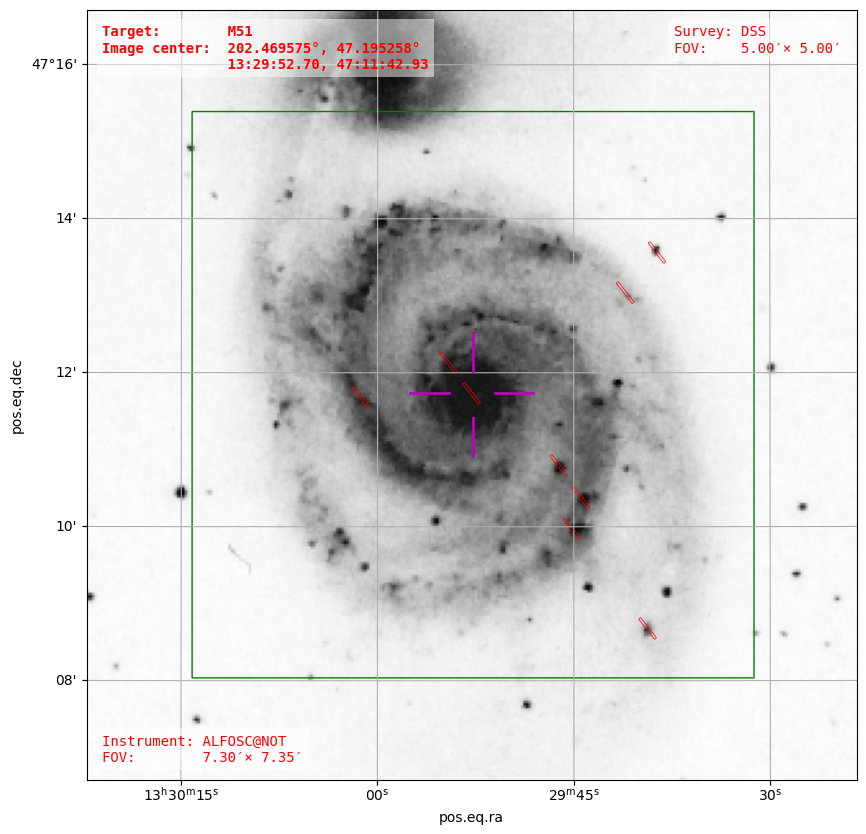

In [8]:
# Central of the image
target = FixedTarget.from_name("M51")

# MOS targets
target_list = FixedTarget(
    SkyCoord(
        ra=[
            202.43819,
            202.435229,
            202.442282,
            202.470046,
            202.477557,
            202.505321,
            202.421083,
            202.414035,
            202.410955,
        ]
        * u.deg,
        dec=[
            47.16618,
            +47.1729860,
            +47.1799447,
            +47.1955599,
            +47.2022091,
            +47.1946285,
            +47.2173295,
            +47.1446491,
            +47.2260180,
        ]
        * u.deg,
    )
)

instrument_fov = InstrumentFOV(
    name="ALFOSC@NOT",
    shape="rectangle",
    width=2048 * 0.2138 * u.arcsec,
    height=2064 * 0.2138 * u.arcsec,
)

slits = []
for coord in target_list.coord:
    slit = Slit(
        coord.ra,
        coord.dec,
        20 * u.arcsec,
        2 * u.arcsec,
        position_angle=38 * u.deg,
    )
    slits.append(slit)

chart = FinderChart(target)
chart.get_image(fov_radius=5 * u.arcmin)
ax = chart.plot_image()
chart.plot_reticle(ax)
chart.plot_instrument_fov(instrument_fov, ax)
chart.plot_slits(slits, ax, show_details=False)
ax.grid()
savefig("plots/example_chart_6.jpg")

# Using your own fits image as background

/Users/vikrantjadhav/Documents/GitHub/finder_charts/src/finder_charts.py:441: UserWarning: The image WCS is not in equatorial coordinates.The position angles are calculated relative to equatorial north pole.
  warnings.warn(


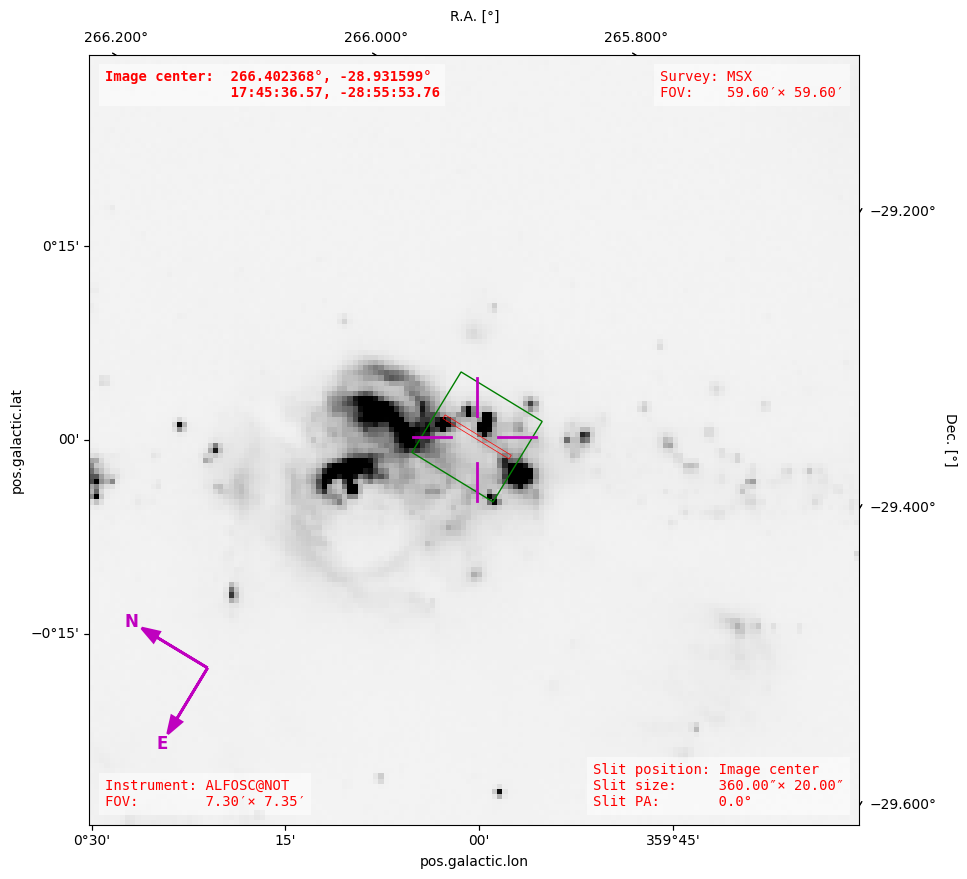

In [9]:
from astropy.utils.data import get_pkg_data_filename
from astropy.io import fits
from astropy.wcs import WCS

instrument_fov = InstrumentFOV(
    name="ALFOSC@NOT",
    shape="rectangle",
    width=2048 * 0.2138 * u.arcsec,
    height=2064 * 0.2138 * u.arcsec,
    position_angle=0 * u.deg,
)

# Load your own .fits file with WCS
# file_name = get_pkg_data_filename('galactic_center/gc_2mass_j.fits')
file_name = get_pkg_data_filename('galactic_center/gc_msx_e.fits')

################################################################################
# Creating a target object at the center of the image
hdu = fits.open(file_name)[0]
wcs = WCS(hdu.header)
# Image center in pixel coordinates
ny, nx = hdu.data.shape
x_center = nx / 2
y_center = ny / 2
# Convert pixel -> sky coordinates
target = FixedTarget(wcs.pixel_to_world(x_center, y_center))
################################################################################
chart = FinderChart(target)
chart.load_image(file_name, survey_name='MSX')

ax = chart.plot_image(vmin=-2.e-5, vmax=2.e-4, show_degrees=True)
chart.plot_reticle(ax)
chart.plot_instrument_fov(instrument_fov, ax)
chart.plot_compass(
    ax,
    frac_length = 0.1,
    x_frac = 0.15,
    y_frac = 0.2,
)

slit = Slit(
    target.coord.icrs.ra,
    target.coord.icrs.dec,
    6 * u.arcmin,
    20 * u.arcsec,
    position_angle=0 * u.deg,
)
chart.plot_slit(slit, ax)

savefig("plots/example_chart_7.png")

# Miscellaneous

In [10]:
import importlib 
import src.finder_charts
importlib.reload(src.finder_charts)
from src.finder_charts import FinderChart, InstrumentFOV, Slit, savefig

# List of SkyView supported surveys

from astroquery.skyview import SkyView
print(SkyView.list_surveys())

{'Allbands:GOODS/HDF/CDF': ['GOODS: Chandra ACIS HB',
                            'GOODS: Chandra ACIS FB',
                            'GOODS: Chandra ACIS SB',
                            'GOODS: VLT VIMOS U',
                            'GOODS: VLT VIMOS R',
                            'GOODS: HST ACS B',
                            'GOODS: HST ACS V',
                            'GOODS: HST ACS I',
                            'GOODS: HST ACS Z',
                            'Hawaii HDF U',
                            'Hawaii HDF B',
                            'Hawaii HDF V0201',
                            'Hawaii HDF V0401',
                            'Hawaii HDF R',
                            'Hawaii HDF I',
                            'Hawaii HDF z',
                            'Hawaii HDF HK',
                            'GOODS: HST NICMOS',
                            'GOODS: VLT ISAAC J',
                            'GOODS: VLT ISAAC H',
                            'GOODS: 